# Retrieve and plot a timeseries
In this notebook we demonstrate how to download a forecast timeseries

## Load dependencies and create folders
In the first cell we load the relevant libraries for this notebook
We also create folders for downloaded data and plots if we want to save them

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cdsapi
import cfgrib
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
import os
import xarray as xr

## Download fields
In the section below, fields are downloaded and stored. We will look at temperature of June 2nd, 2024. The resulting data file size is roughly 500 Mb.

In [ ]:
target_path = os.path.join('data', 'temperature_timeseries.grib')


dataset = "reanalysis-pan-carra"
request = {
    "level_type": "single_levels",
    "variable": ["2m_temperature"],
    "product_type": "forecast",
    "time": ["00:00", "12:00"],
    "leadtime_hour": [
        "1",
        "2",
        "3",
        "4",
        "5",
        "6",
        "7",
        "8",
        "9",
        "10",
        "11",
        "12",
        "13",
        "14",
        "15",
        "16",
        "17",
        "18"
    ],
    "year": ["2024"],
    "month": ["06"],
    "day": ["02"],
    "data_format": "grib"
}

client = cdsapi.Client()
client.retrieve(dataset, request).download(target_path)

In [4]:
ds = cfgrib.open_dataset(target_path)
ds

<xarray.Dataset> Size: 1GB
Dimensions:            (time: 2, step: 18, y: 2869, x: 2869)
Coordinates:
  * time               (time) datetime64[ns] 16B 2024-06-02 2024-06-02T12:00:00
  * step               (step) timedelta64[ns] 144B 01:00:00 ... 18:00:00
    valid_time         (time, step) datetime64[ns] 288B ...
    latitude           (y, x) float64 66MB ...
    longitude          (y, x) float64 66MB ...
    heightAboveGround  float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    t2m                (time, step, y, x) float32 1GB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             enmi
    GRIB_centreDescription:  Oslo
    GRIB_subCentre:          255
    Conventions:             CF-1.7
    institution:             Oslo
    history:                 2026-06-10T11:20 GRIB to CDM+CF via cfgrib-0.9.1...

## Plot a timeseries of temperature
We now plot the temperature over a coordinate in Denmark. Notice the overlapping period between the two forecasts.

Nearest grid point coordinates: lat=55.661, lon=12.448


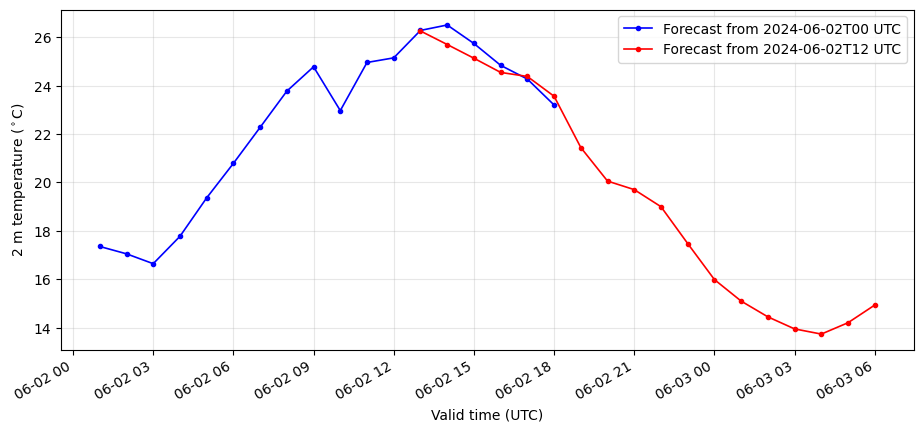

In [8]:
target_lat = 55.65
target_lon = 12.45

lat2d = ds["latitude"].values
lon2d = ((ds["longitude"].values + 180) % 360) - 180 
dist = (lat2d - target_lat) ** 2 + (lon2d - target_lon) ** 2
iy, ix = np.unravel_index(np.argmin(dist), dist.shape)
print(f"Nearest grid point coordinates: lat={lat2d[iy, ix]:.3f}, lon={lon2d[iy, ix]:.3f}")

point = ds["t2m"].isel(y=iy, x=ix) - 273.15

colors = ["blue", "red"]
fig, ax = plt.subplots(figsize=(11, 5))
for i in range(ds.sizes["time"]):
    run_time = np.datetime64(ds["time"].values[i], "h")
    ax.plot(ds["valid_time"].values[i], point.isel(time=i).values,
            marker="o", ms=3, lw=1.2, color=colors[i],
            label=f"Forecast from {str(run_time)} UTC")
ax.set_xlabel("Valid time (UTC)")
ax.set_ylabel("2 m temperature ($^\\circ$C)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()

fig.savefig(os.path.join("plots", "temperature_timeseries.png"),
            dpi=150, bbox_inches="tight")
plt.show()